In [388]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [389]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent / "src"))

In [390]:
from models import NDVIClimatologyGAM

from ipywidgets import interact
from IPython.display import display


import importlib

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn import linear_model

from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from data import utils
from features import features

from pygam import LinearGAM, s



In [391]:
non_spectral_df = pd.read_csv("../data/raw/non_spectral_df.csv", index_col=0)
non_spectral_df["Timestamp"] = pd.to_datetime(non_spectral_df["Timestamp"])
spectral_df = pd.read_csv("../data/raw/spectral_df.csv", index_col=0)
spectral_df["Timestamp"] = pd.to_datetime(spectral_df["Timestamp"])
grouped_spectral_df = pd.read_csv("../data/raw/grouped_spectral_df.csv", index_col=0)
grouped_spectral_df["Timestamp"] = pd.to_datetime(grouped_spectral_df["Timestamp"])
master_df = utils.merge_with_master(grouped_spectral_df, non_spectral_df)
master_df.head()

,Timestamp,NDVI_mean,NDVI_std,NDWI_mean,NDWI_std,NDRE_mean,NDRE_std,volumetric_soil_water_layer_1,volumetric_soil_water_layer_2,volumetric_soil_water_layer_3,volumetric_soil_water_layer_4,soil_temperature_level_1,soil_temperature_level_2,soil_temperature_level_3,soil_temperature_level_4,temperature_2m,temperature_2m_min,temperature_2m_max,surface_solar_radiation_downwards_sum,precipitation
0,2018-01-07,0.454175,0.017789,0.154850,0.001513,0.301027,0.005391,0.277943,0.320916,0.297231,0.270322,298.093380,296.435354,293.480139,291.139993,296.411982,288.101550,305.198672,3.187154e+07,0.000000
1,2018-03-03,0.629801,0.031419,0.310717,0.025493,0.438958,0.033150,0.275499,0.294964,0.281848,0.269882,296.319232,295.264591,293.797097,292.708587,293.174303,284.739623,300.874879,2.653625e+07,5.928807
2,2018-06-01,0.330054,0.013942,0.073200,0.005519,0.220654,0.008582,0.387392,0.309780,0.338261,0.271122,283.614288,284.567219,286.777798,290.473939,281.743066,275.021431,288.422674,1.504906e+07,0.000000
3,2018-06-06,0.289118,0.015937,-0.017437,0.002453,0.180388,0.010207,0.336953,0.310565,0.336209,0.271163,281.924616,282.769941,285.820755,290.178382,280.752142,274.098569,288.798194,1.452415e+07,0.000000
4,2018-06-11,0.264834,0.027659,-0.018403,0.011886,0.172670,0.016877,0.307676,0.305746,0.333914,0.271199,282.930785,283.265651,285.249282,289.847651,281.838309,276.769477,289.060574,1.396338e+07,0.000000


In [392]:
plot_df = master_df[master_df["Timestamp"] < pd.to_datetime("2026-01-01")].copy()
plot_df = plot_df.sort_values("Timestamp")
plot_df["doy"] = plot_df["Timestamp"].dt.dayofyear

In [400]:
doys = plot_df["doy"].values.reshape(-1, 1)
ndvi = plot_df["NDVI_mean"].values

In [401]:
gam = NDVIClimatologyGAM(n_splines=30).gridsearch(doys=doys, ndvi=ndvi)

100% (25 of 25) |########################| Elapsed Time: 0:00:00 Time:  0:00:000:00


In [402]:
gam.summary()

ClimatologyGAM
────────────────────────────────────────────────────────────
Observations                   305
Response                       NDVI

Phenological Events
────────────────────────────────────────────────────────────
Start-of-Season interval       (239, 323)
Selected SOS DOY               239
Peak Growth                    TODO
Senescence DOY                 174

Seasonal Metrics
────────────────────────────────────────────────────────────
Season Length                  300
Peak NDVI                      0.68
Base NDVI                      0.15
Average NDVI                   0.32


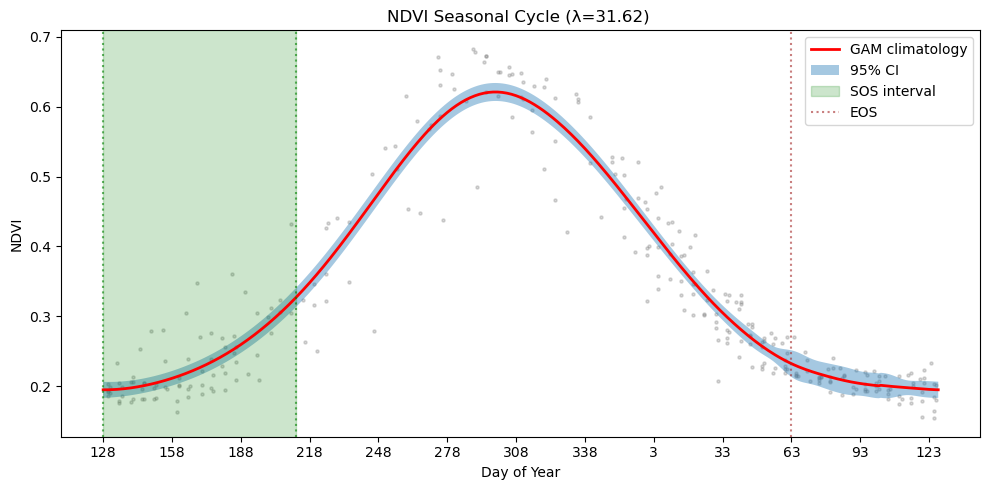

In [403]:
gam.plot_climatology(shifted=True, season_lines=True)

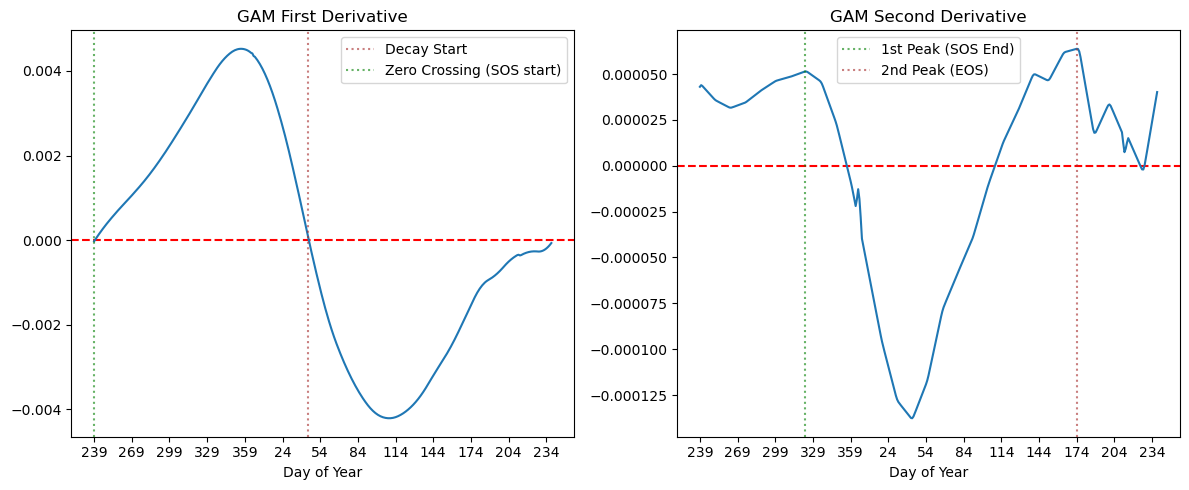

In [405]:
gam.plot_derivatives(shifted=True, crit_lines=True)